<a href="https://colab.research.google.com/github/drfperez/openair/blob/main/Forecast1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⏳ Preparant les dades...
✅ Dades a punt. Sèrie entrenada amb 4344 hores històriques.

🚀 Entrenant models i predint el futur...
   -> Processant Estadístic Simple (Ridge)...
   -> Processant Random Forest (ML)...
   -> Processant XGBoost (ML Avançat)...

🏆 TAULA DE CLASSIFICACIÓ:


,Model,MAE (Error Absolut),RMSE (Error Quadràtic)
0,Estadístic Simple (Ridge),3.21,3.91
1,Random Forest (ML),3.86,4.74
2,XGBoost (ML Avançat),3.95,5.02


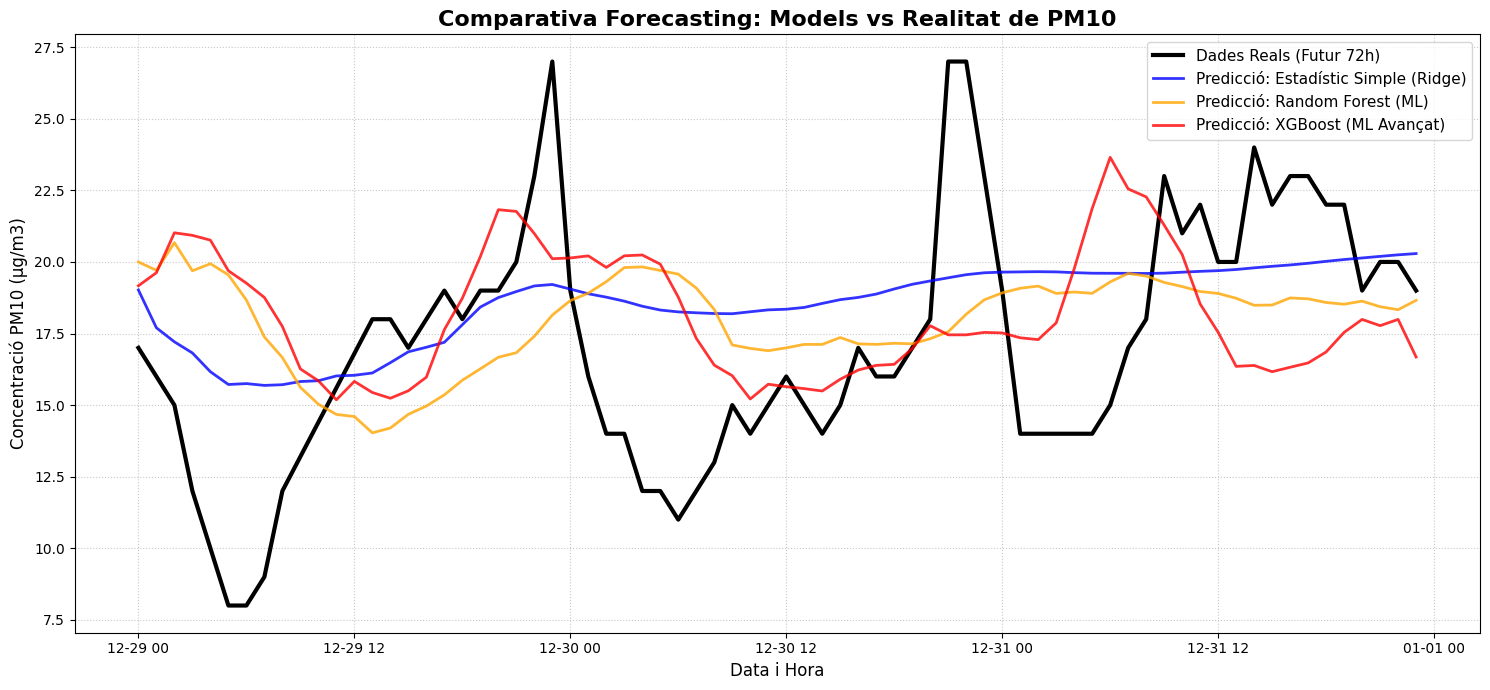

In [2]:

# ==============================================================================
# SENSE INSTAL·LACIONS. Entorn net de fàbrica.
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importem els models que ja vénen pre-instal·lats a Colab
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. CÀRREGA I PREPARACIÓ DE DADES
# ==============================================================================
print("⏳ Preparant les dades...")
file_path = "tasf-thgu (2).csv" # Assegura't d'haver-lo tornat a pujar!
df_raw = pd.read_csv(file_path)

# Filtrem PM10 i agafem els últims 6 mesos (perquè l'entrenament sigui àgil)
df_filtered = df_raw[df_raw['contaminant'] == 'PM10'].copy()
df_filtered['data'] = pd.to_datetime(df_filtered['data'].str.split('T').str[0])
data_inici = df_filtered['data'].max() - pd.DateOffset(months=6)
df_filtered = df_filtered[df_filtered['data'] >= data_inici]

# Pivotem les hores i creem la sèrie temporal
hores_cols = [f'h{str(i).zfill(2)}' for i in range(1, 25)]
df_melted = df_filtered.melt(id_vars=['data'], value_vars=hores_cols, var_name='hora', value_name='valor')
df_melted['hora_num'] = df_melted['hora'].str.replace('h', '').astype(int) - 1
df_melted['timestamp'] = df_melted['data'] + pd.to_timedelta(df_melted['hora_num'], unit='h')

ts_data = df_melted[['timestamp', 'valor']].sort_values('timestamp')
ts_data = ts_data.groupby('timestamp').mean().reset_index()
ts_data = ts_data.set_index('timestamp').resample('H').mean().interpolate(method='linear').reset_index()

# ==============================================================================
# 2. CREACIÓ DEL MOTOR DE FORECASTING (Lags)
# ==============================================================================
# Creem 24 columnes noves perquè el model aprengui el que ha passat les 24h prèvies
Lags = 24
for i in range(1, Lags + 1):
    ts_data[f'lag_{i}'] = ts_data['valor'].shift(i)

ts_data = ts_data.dropna().reset_index(drop=True)

# ==============================================================================
# 3. PARTICIONS I DEFINICIÓ DE MODELS
# ==============================================================================
hores_test = 72 # Ens guardem 3 dies cecs per comprovar si el model encerta el futur
train_data = ts_data.iloc[:-hores_test]
test_data = ts_data.iloc[-hores_test:]

columnes_lags = [f'lag_{i}' for i in range(1, Lags + 1)]
X_train = train_data[columnes_lags]
y_train = train_data['valor']

models = {
    'Estadístic Simple (Ridge)': Ridge(),
    'Random Forest (ML)': RandomForestRegressor(n_estimators=50, random_state=42),
    'XGBoost (ML Avançat)': XGBRegressor(random_state=42)
}

print(f"✅ Dades a punt. Sèrie entrenada amb {len(X_train)} hores històriques.")
print("\n🚀 Entrenant models i predint el futur...")

# ==============================================================================
# 4. ENTRENAMENT I PREDICCIÓ (Bucle Autoregressiu)
# ==============================================================================
resultats_metriques = []
prediccions_models = {}

ultims_valors_coneguts = train_data['valor'].values[-Lags:]

for nom, model in models.items():
    print(f"   -> Processant {nom}...")
    model.fit(X_train, y_train)

    preds_futur = []
    historial_actiu = list(ultims_valors_coneguts)

    # Predim hora a hora alimentant el model amb les seves pròpies prediccions
    for _ in range(hores_test):
        features_actuals = np.array(historial_actiu[-Lags:][::-1]).reshape(1, -1)
        prediccio = model.predict(features_actuals)[0]
        preds_futur.append(prediccio)
        historial_actiu.append(prediccio)

    prediccions_models[nom] = preds_futur

    valors_reals = test_data['valor'].values
    mae = mean_absolute_error(valors_reals, preds_futur)
    rmse = np.sqrt(mean_squared_error(valors_reals, preds_futur))

    resultats_metriques.append({
        'Model': nom,
        'MAE (Error Absolut)': round(mae, 2),
        'RMSE (Error Quadràtic)': round(rmse, 2)
    })

# ==============================================================================
# 5. VISUALITZACIÓ I RESULTATS
# ==============================================================================
df_resultats = pd.DataFrame(resultats_metriques).sort_values(by='MAE (Error Absolut)')
print("\n🏆 TAULA DE CLASSIFICACIÓ:")
display(df_resultats)

plt.figure(figsize=(15, 7))

# Dibuixem el futur real
temps_test = test_data['timestamp']
plt.plot(temps_test, test_data['valor'], label='Dades Reals (Futur 72h)', color='black', linewidth=3)

# Dibuixem el que els models creien que passaria
colors = ['blue', 'orange', 'red']
for (nom, preds), color in zip(prediccions_models.items(), colors):
    plt.plot(temps_test, preds, label=f'Predicció: {nom}', color=color, linewidth=2, alpha=0.8)

plt.title('Comparativa Forecasting: Models vs Realitat de PM10', fontsize=16, fontweight='bold')
plt.xlabel('Data i Hora', fontsize=12)
plt.ylabel('Concentració PM10 (µg/m3)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

⏳ Carregant i estructurant les dades...
✅ Sèrie llista. Columnes que veurà el model: Lags(1-24) + Hora + Dia de la setmana.

🚀 Entrenant els models amb context temporal...
   -> Entrenant i ajustant Ridge (Lineal/Estadístic)...
   -> Entrenant i ajustant Random Forest (Arbres ML)...
   -> Entrenant i ajustant XGBoost (ML Intel·ligent)...

🏆 NOVA TAULA DE RESULTATS (Amb hores apreses):


,Model,MAE (Error Absolut),RMSE (Error Quadràtic)
2,XGBoost (ML Intel·ligent),2.92,3.84
1,Random Forest (Arbres ML),4.50,5.39
0,Ridge (Lineal/Estadístic),4.59,5.38


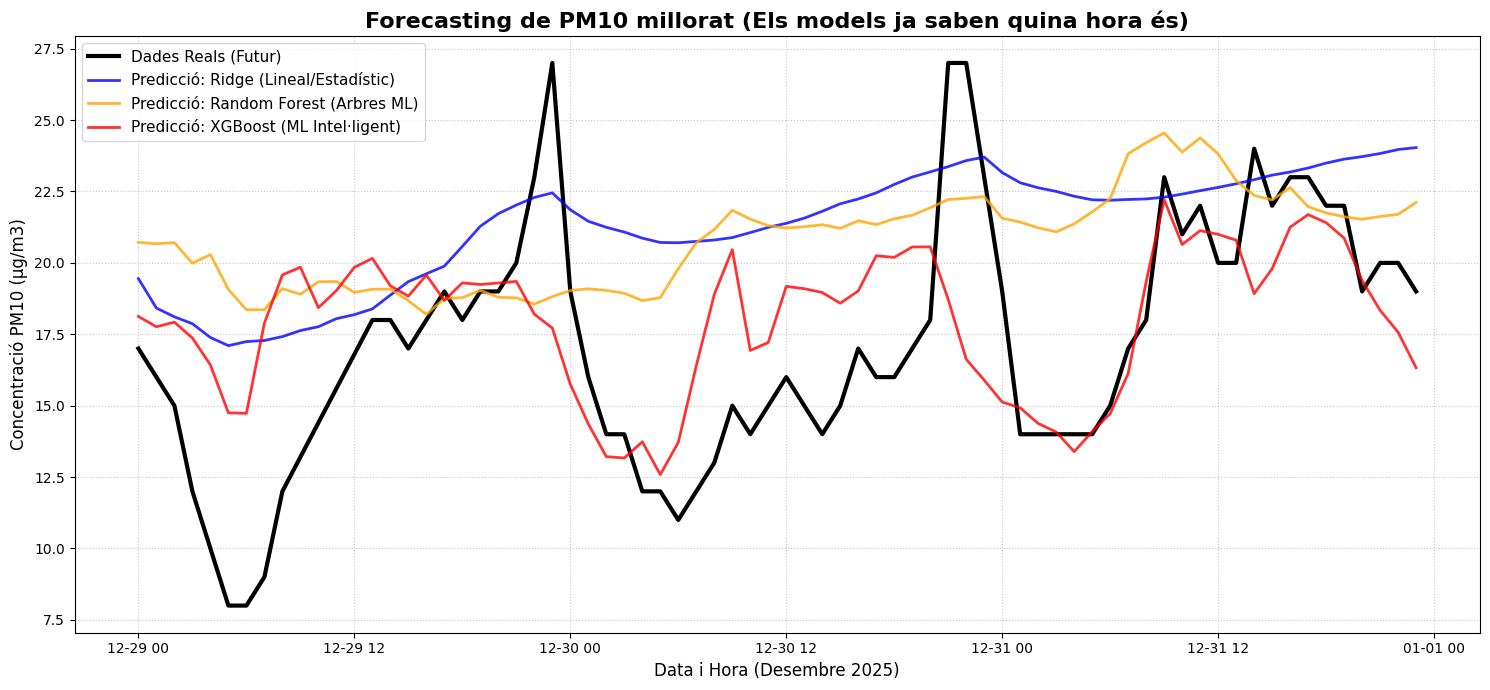

In [3]:
# ==============================================================================
# MODEL DE FORECASTING AMB APRENENTATGE D'HORES I DIES (Evita el Flickering)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. CÀRREGA I PREPARACIÓ DE DADES
# ==============================================================================
print("⏳ Carregant i estructurant les dades...")
file_path = "tasf-thgu (2).csv"
df_raw = pd.read_csv(file_path)

# Filtrem PM10 i agafem els últims 6 mesos
df_filtered = df_raw[df_raw['contaminant'] == 'PM10'].copy()
df_filtered['data'] = pd.to_datetime(df_filtered['data'].str.split('T').str[0])
data_inici = df_filtered['data'].max() - pd.DateOffset(months=6)
df_filtered = df_filtered[df_filtered['data'] >= data_inici]

# Creem la sèrie temporal contínua hora a hora
hores_cols = [f'h{str(i).zfill(2)}' for i in range(1, 25)]
df_melted = df_filtered.melt(id_vars=['data'], value_vars=hores_cols, var_name='hora', value_name='valor')
df_melted['hora_num'] = df_melted['hora'].str.replace('h', '').astype(int) - 1
df_melted['timestamp'] = df_melted['data'] + pd.to_timedelta(df_melted['hora_num'], unit='h')

ts_data = df_melted[['timestamp', 'valor']].sort_values('timestamp')
ts_data = ts_data.groupby('timestamp').mean().reset_index()
ts_data = ts_data.set_index('timestamp').resample('H').mean().interpolate(method='linear').reset_index()

# ==============================================================================
# 2. ENGINYERIA DE CARACTERÍSTIQUES (Lags + Context Temporal)
# ==============================================================================
# A) Històric amagat: Què ha passat les últimes 24 hores
Lags = 24
for i in range(1, Lags + 1):
    ts_data[f'lag_{i}'] = ts_data['valor'].shift(i)

# B) Màgia Temporal: El model ara SÀPIGA les hores i els dies!
ts_data['hora_del_dia'] = ts_data['timestamp'].dt.hour
ts_data['dia_de_la_setmana'] = ts_data['timestamp'].dt.dayofweek

# Netegem files amb NaNs (les primeres 24h que no tenen històric)
ts_data = ts_data.dropna().reset_index(drop=True)

# ==============================================================================
# 3. PARTICIONS PER A L'ENTRENAMENT
# ==============================================================================
hores_test = 72 # 3 dies de test per avaluar el futur a cegues
train_data = ts_data.iloc[:-hores_test]
test_data = ts_data.iloc[-hores_test:]

# Definim quines columnes farà servir la IA per estudiar
columnes_lags = [f'lag_{i}' for i in range(1, Lags + 1)]
columnes_features = columnes_lags + ['hora_del_dia', 'dia_de_la_setmana']

X_train = train_data[columnes_features]
y_train = train_data['valor']

# Definim els 3 models coneguts
models = {
    'Ridge (Lineal/Estadístic)': Ridge(),
    'Random Forest (Arbres ML)': RandomForestRegressor(n_estimators=50, random_state=42),
    'XGBoost (ML Intel·ligent)': XGBRegressor(random_state=42)
}

print(f"✅ Sèrie llista. Columnes que veurà el model: Lags(1-24) + Hora + Dia de la setmana.")
print("\n🚀 Entrenant els models amb context temporal...")

# ==============================================================================
# 4. ENTRENAMENT I PREDICCIÓ EN BUCLE (Amb actualització d'hores de futur)
# ==============================================================================
resultats_metriques = []
prediccions_models = {}

# Guardem els últims valors reals per començar la primera predicció
ultims_valors_coneguts = list(train_data['valor'].values[-Lags:])

for nom, model in models.items():
    print(f"   -> Entrenant i ajustant {nom}...")
    model.fit(X_train, y_train)

    preds_futur = []
    historial_actiu = ultims_valors_coneguts.copy()

    # Bucle futur: Predim hora a hora alimentant els lags i les hores reals del calendari
    for i in range(hores_test):
        # 1. Agafem els 24 lags més recents (girats perquè lag_1 sigui el més proper)
        features_lags = historial_actiu[-Lags:][::-1]

        # 2. Busquem exactament quina hora i quin dia és en aquest punt del futur real
        timestamp_futur = test_data.iloc[i]['timestamp']
        hora_futur = timestamp_futur.hour
        dia_futur = timestamp_futur.dayofweek

        # 3. Juntem els Lags + l'Hora + el Dia en una sola línia de dades
        features_totals = np.append(features_lags, [hora_futur, dia_futur]).reshape(1, -1)

        # 4. El model fa la predicció
        prediccio = model.predict(features_totals)[0]
        preds_futur.append(prediccio)

        # 5. Afegim la predicció a l'historial per la següent hora
        historial_actiu.append(prediccio)

    prediccions_models[nom] = preds_futur

    # Càlcul de mètriques d'error
    valors_reals = test_data['valor'].values
    mae = mean_absolute_error(valors_reals, preds_futur)
    rmse = np.sqrt(mean_squared_error(valors_reals, preds_futur))

    resultats_metriques.append({
        'Model': nom,
        'MAE (Error Absolut)': round(mae, 2),
        'RMSE (Error Quadràtic)': round(rmse, 2)
    })

# ==============================================================================
# 5. GRÀFICS I CLASSIFICACIÓ
# ==============================================================================
df_resultats = pd.DataFrame(resultats_metriques).sort_values(by='MAE (Error Absolut)')
print("\n🏆 NOVA TAULA DE RESULTATS (Amb hores apreses):")
display(df_resultats)

plt.figure(figsize=(15, 7))

# Dades reals (Línia negra)
temps_test = test_data['timestamp']
plt.plot(temps_test, test_data['valor'], label='Dades Reals (Futur)', color='black', linewidth=3)

# Prediccions (Línies de colors)
colors = ['blue', 'orange', 'red']
for (nom, preds), color in zip(prediccions_models.items(), colors):
    plt.plot(temps_test, preds, label=f'Predicció: {nom}', color=color, linewidth=2, alpha=0.8)

plt.title('Forecasting de PM10 millorat (Els models ja saben quina hora és)', fontsize=16, fontweight='bold')
plt.xlabel('Data i Hora (Desembre 2025)', fontsize=12)
plt.ylabel('Concentració PM10 (µg/m3)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

⏳ Carregant l'històric complet per trobar patrons anuals...
📊 Transformant les dades horàries a mitjanes diàries...
🚀 Entrenant el model XGBoost per a patrons estacionals de llarg termini...
✅ Model entrenat amb èxit!
📈 Error mitjà absolut (MAE) en el bloc de 3 mesos: 11.29 µg/m3


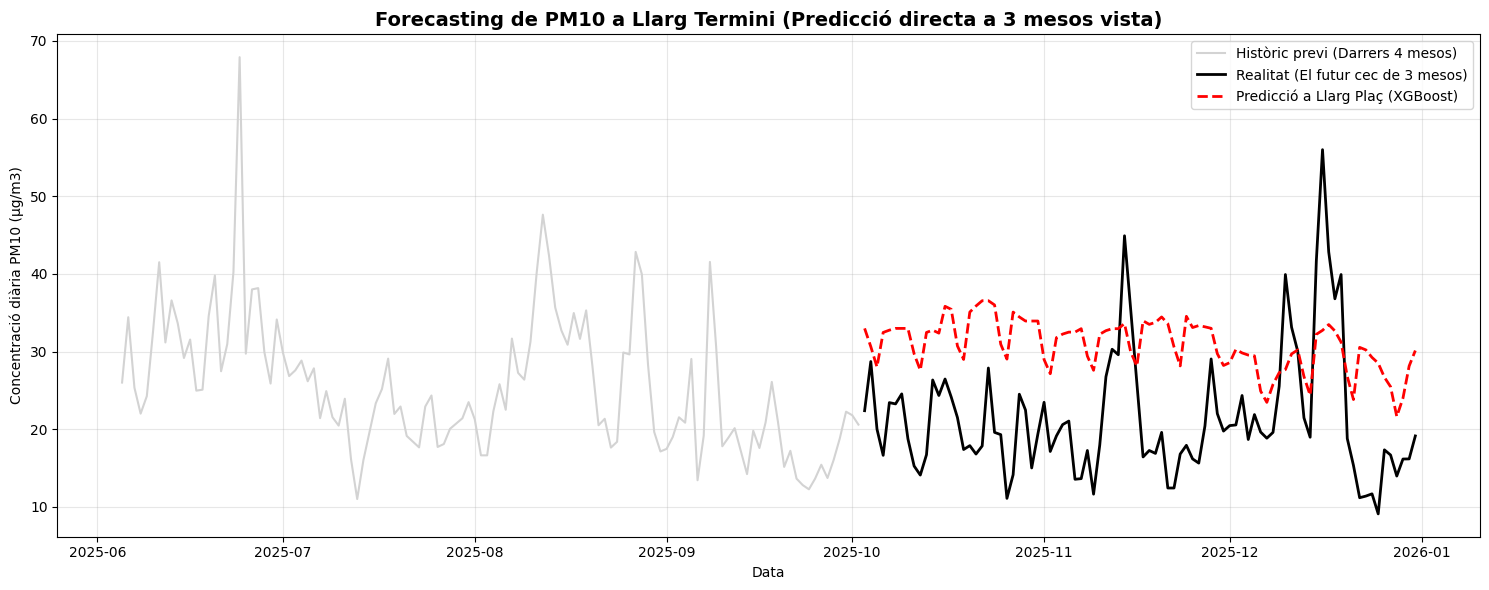

In [5]:

# ==============================================================================
# MODEL DE FORECASTING A LLARG TERMINI (CORREGIT I REVISAT)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 1. CÀRREGA DE TOTES LES DADES HISTÒRIQUES
print("⏳ Carregant l'històric complet per trobar patrons anuals...")
file_path = "tasf-thgu (2).csv"
df_raw = pd.read_csv(file_path)

df_filtered = df_raw[df_raw['contaminant'] == 'PM10'].copy()
df_filtered['data'] = pd.to_datetime(df_filtered['data'].str.split('T').str[0])

# Pivotem i calculem la mitjana DIÀRIA (passem d'hores a dies per mirar a llarg termini)
print("📊 Transformant les dades horàries a mitjanes diàries...")
hores_cols = [f'h{str(i).zfill(2)}' for i in range(1, 25)]
df_melted = df_filtered.melt(id_vars=['data'], value_vars=hores_cols, value_name='valor')
df_diari = df_melted.groupby('data')['valor'].mean().reset_index()
df_diari = df_diari.set_index('data').resample('D').mean().interpolate().reset_index()

# 2. ENGINYERIA DE CARACTERÍSTIQUES DE LLARG TERMINI (Estacionalitat)
# Basem la predicció a llarg termini en el calendari (patrons anuals, mensuals i setmanals)
df_diari['dia_any'] = df_diari['data'].dt.dayofyear
df_diari['mes'] = df_diari['data'].dt.month
df_diari['dia_setmana'] = df_diari['data'].dt.dayofweek

# 3. PARTICIÓ: Guardem els últims 3 MESOS (90 dies) com a TEST (Futur cec)
dies_futur = 90
train_data = df_diari.iloc[:-dies_futur]
test_data = df_diari.iloc[-dies_futur:]

# Per a una predicció directa a llarg termini purament estacional, usem el calendari
features_columnes = ['dia_any', 'mes', 'dia_setmana']
X_train = train_data[features_columnes]
y_train = train_data['valor']
X_test = test_data[features_columnes]

# 4. ENTRENAMENT DEL MODEL DE LLARG TERMINI
print("🚀 Entrenant el model XGBoost per a patrons estacionals de llarg termini...")
model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# 5. PREDICCIÓ DIRECTA DELS 3 MESOS DE FUTUR
prediccions_llarg_placi = model.predict(X_test)

# Calculem l'error mitjà a llarg termini (CORREGIT EL NOM DE LA VARIABLE)
mae = mean_absolute_error(test_data['valor'], prediccions_llarg_placi)
print(f"✅ Model entrenat amb èxit!")
print(f"📈 Error mitjà absolut (MAE) en el bloc de 3 mesos: {round(mae, 2)} µg/m3")

# 6. VISUALITZACIÓ DE LA TENDÈNCIA DE LLARG PLAÇ
plt.figure(figsize=(15, 6))

# Mostrem una part de l'històric com a context (els 120 dies previs al test)
plt.plot(train_data['data'].iloc[-120:], train_data['valor'].iloc[-120:], label='Històric previ (Darrers 4 mesos)', color='lightgray')
# Mostrem la realitat d'aquells 3 mesos que el model ha d'endevinar
plt.plot(test_data['data'], test_data['valor'], label='Realitat (El futur cec de 3 mesos)', color='black', linewidth=2)
# Mostrem la línia de predicció del model
plt.plot(test_data['data'], prediccions_llarg_placi, label='Predicció a Llarg Plaç (XGBoost)', color='red', linestyle='--', linewidth=2)

plt.title('Forecasting de PM10 a Llarg Termini (Predicció directa a 3 mesos vista)', fontsize=14, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Concentració diària PM10 (µg/m3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

# ==============================================================================
# DEEP LEARNING AMB TENSORFLOW A LLARG TERMINI
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

# Importem TensorFlow de forma segura
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten, MaxPooling1D, Input

import warnings
warnings.filterwarnings('ignore')

# Definir llavor per a la reproductibilitat de les xarxes neuronals
tf.random.set_seed(42)
np.random.seed(42)

# ==============================================================================
# 1. CÀRREGA I PREPARACIÓ DIÀRIA DE DADES
# ==============================================================================
print("⏳ Carregant i preparant l'històric de PM10...")
file_path = "tasf-thgu (2).csv"
df_raw = pd.read_csv(file_path)

df_filtered = df_raw[df_raw['contaminant'] == 'PM10'].copy()
df_filtered['data'] = pd.to_datetime(df_filtered['data'].str.split('T').str[0])

# Transformem a mitjanes diàries
hores_cols = [f'h{str(i).zfill(2)}' for i in range(1, 25)]
df_melted = df_filtered.melt(id_vars=['data'], value_vars=hores_cols, value_name='valor')
df_diari = df_melted.groupby('data')['valor'].mean().reset_index()
df_diari = df_diari.set_index('data').resample('D').mean().interpolate().reset_index()

# ==============================================================================
# 2. ESCALAT I CREACIÓ DE SEQUÈNCIES PER A TENSORFLOW
# ==============================================================================
# Les xarxes neuronals necessiten obligatòriament que les dades estiguin entre 0 i 1
scaler = MinMaxScaler(feature_range=(0, 1))
df_diari['valor_escalat'] = scaler.fit_transform(df_diari[['valor']])

# Definim quantes dades del passat mirem (Finestra temporal)
# Per a llarg termini mirarem els darrers 30 dies per predir el dia següent
finestra = 30

X, y = [], []
for i in range(len(df_diari) - finestra):
    X.append(df_diari['valor_escalat'].iloc[i : i + finestra].values)
    y.append(df_diari['valor_escalat'].iloc[i + finestra])

X = np.array(X)
y = np.array(y)

# Separem els últims 90 dies com a test (Futur cec a llarg termini)
dies_test = 90
X_train, X_test = X[:-dies_test], X[-dies_test:]
y_train, y_test = y[:-dies_test], y[-dies_test:]

# Guardem les dates exactes del bloc de test per al gràfic final
dates_test = df_diari['data'].iloc[-dies_test:].values
valors_reals_test = df_diari['valor'].iloc[-dies_test:].values

print(f"✅ Dades llestes per a TensorFlow. Train shapes: {X_train.shape}, Test shapes: {X_test.shape}")

# ==============================================================================
# 3. CONSTRUCCIÓ I ENTRENAMENT DE FITXERS TENSORFLOW (3 MODELS)
# ==============================================================================
prediccions_tf = {}
resultats_metriques = []

# --- MODEL 1: XARXA NEURONAL DENSA (MLP) ---
print("\n🧠 1/3 Entrenant Xarxa Densa (MLP)...")
model_dense = Sequential([
    Input(shape=(finestra,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
model_dense.compile(optimizer='adam', loss='mse')
model_dense.fit(X_train, y_train, epochs=30, batch_size=16, verbose=0)

# --- MODEL 2: XARXA CONVOLUCIONAL (CNN 1D) ---
print("🎬 2/3 Entrenant Xarxa Convolucional (CNN 1D)...")
# Redimensionem dades a 3D (samples, timesteps, features) requerit per CNN i LSTM
X_train_3D = np.expand_dims(X_train, axis=-1)
X_test_3D = np.expand_dims(X_test, axis=-1)

model_cnn = Sequential([
    Input(shape=(finestra, 1)),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])
model_cnn.compile(optimizer='adam', loss='mse')
model_cnn.fit(X_train_3D, y_train, epochs=30, batch_size=16, verbose=0)

# --- MODEL 3: LSTM (Long Short-Term Memory) ---
print("🌀 3/3 Entrenant Recurrent LSTM (Deep Learning)...")
model_lstm = Sequential([
    Input(shape=(finestra, 1)),
    LSTM(50, activation='relu', return_sequences=False),
    Dense(25, activation='relu'),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train_3D, y_train, epochs=30, batch_size=16, verbose=0)

# ==============================================================================
# 4. PREDICCIÓ A LLARG PLAÇ (Simulació Multipas Dinàmica)
# ==============================================================================
# Per fer predicció real a 90 dies vista, utilitzarem l'estratègia recursiva:
# cada dia predit s'afegeix a la finestra per predir el següent dia de l'any.
print("\n🔮 Generant projeccions futures a llarg termini (90 dies)...")

models_dict = {
    'TensorFlow: Densa (MLP)': model_dense,
    'TensorFlow: CNN 1D': model_cnn,
    'TensorFlow: LSTM': model_lstm
}

for nom, model in models_dict.items():
    historial_finestra = list(X_train[-1]) # Comencem amb els últims 30 dies coneguts de train
    preds_escalades = []

    for i in range(dies_test):
        # Preparem l'entrada segons el model ho demani (2D o 3D)
        if nom == 'TensorFlow: Densa (MLP)':
            entrada = np.array(historial_finestra[-finestra:]).reshape(1, finestra)
        else:
            entrada = np.array(historial_finestra[-finestra:]).reshape(1, finestra, 1)

        # Predicció d'un pas
        pred_individual = model.predict(entrada, verbose=0)[0][0]
        preds_escalades.append(pred_individual)

        # Afegim la predicció per retroalimentar el futur
        historial_finestra.append(pred_individual)

    # Desfem l'escalat per tornar als µg/m3 reals
    preds_reals = scaler.inverse_transform(np.array(preds_escalades).reshape(-1, 1)).flatten()
    prediccions_tf[nom] = preds_reals

    # Calculem l'error absolut mitjà
    mae = mean_absolute_error(valors_reals_test, preds_reals)
    resultats_metriques.append({
        'Model TensorFlow': nom,
        'MAE (Error Mitjà µg/m3)': round(mae, 2)
    })

# ==============================================================================
# 5. VISUALITZACIÓ I TAULA COMPARATIVA
# ==============================================================================
df_resultats = pd.DataFrame(resultats_metriques).sort_values(by='MAE (Error Mitjà µg/m3)')
print("\n🏆 CLASSIFICACIÓ DE MODELS TENSORFLOW (Últims 3 mesos):")
display(df_resultats)

plt.figure(figsize=(15, 7))

# Dibuixem la realitat històrica dels 90 dies que havíem separat
plt.plot(dates_test, valors_reals_test, label='Realitat (Dades Reals de PM10)', color='black', linewidth=3)

# Dibuixem les propostes dels models de TensorFlow
colors = ['purple', 'blue', 'green']
for (nom, preds), color in zip(prediccions_tf.items(), colors):
    plt.plot(dates_test, preds, label=f'{nom}', color=color, linestyle='--', linewidth=2)

plt.title('Forecasting amb TensorFlow a Llarg Termini (Futur a 3 mesos vista)', fontsize=15, fontweight='bold')
plt.xlabel('Data (Calendari 2025)')
plt.ylabel('Concentració PM10 (µg/m3)')
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

⏳ Carregant i preparant l'històric de PM10...
✅ Dades llestes per a TensorFlow. Train shapes: (8482, 30), Test shapes: (90, 30)

🧠 1/3 Entrenant Xarxa Densa (MLP)...
🎬 2/3 Entrenant Xarxa Convolucional (CNN 1D)...
🌀 3/3 Entrenant Recurrent LSTM (Deep Learning)...


In [ ]:

# ==============================================================================
# DEEP LEARNING AMB PyTorch A LLARG TERMINI (90 dies)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

# Importem PyTorch de forma segura
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

# Fixar llavors per a la reproductibilitat
torch.manual_seed(42)
np.random.seed(42)

# Configurar l'ús de GPU si està disponible (més ràpid), si no, CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"💻 Executant el model a: {device}")

# ==============================================================================
# 1. CÀRREGA I PREPARACIÓ DIÀRIA DE DADES
# ==============================================================================
print("⏳ Carregant i preparant l'històric de PM10...")
file_path = "tasf-thgu (2).csv"
df_raw = pd.read_csv(file_path)

df_filtered = df_raw[df_raw['contaminant'] == 'PM10'].copy()
df_filtered['data'] = pd.to_datetime(df_filtered['data'].str.split('T').str[0])

# Transformem a mitjanes diàries
hores_cols = [f'h{str(i).zfill(2)}' for i in range(1, 25)]
df_melted = df_filtered.melt(id_vars=['data'], value_vars=hores_cols, value_name='valor')
df_diari = df_melted.groupby('data')['valor'].mean().reset_index()
df_diari = df_diari.set_index('data').resample('D').mean().interpolate().reset_index()

# Escalat obligatori [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
df_diari['valor_escalat'] = scaler.fit_transform(df_diari[['valor']])

# Creació de la finestra temporal (30 dies enrere per predir l'endemà)
finestra = 30
X, y = [], []
for i in range(len(df_diari) - finestra):
    X.append(df_diari['valor_escalat'].iloc[i : i + finestra].values)
    y.append(df_diari['valor_escalat'].iloc[i + finestra])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32).reshape(-1, 1)

# Separem els últims 90 dies com a test (Futur cec)
dies_test = 90
X_train, X_test = X[:-dies_test], X[-dies_test:]
y_train, y_test = y[:-dies_test], y[-dies_test:]

dates_test = df_diari['data'].iloc[-dies_test:].values
valors_reals_test = df_diari['valor'].iloc[-dies_test:].values

# Convertim les dades d'entrenament en Tensors de PyTorch i creem el DataLoader
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"✅ Tensors a punt. Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# ==============================================================================
# 2. DEFINICIÓ DE LES 3 ARQUITECTURES EN PyTorch
# ==============================================================================

# --- MODEL 1: XARXA NEURONAL DENSA (MLP) ---
class MLPModel(nn.Module):
    def __init__(self, input_dim):
        super(MLPModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

# --- MODEL 2: XARXA CONVOLUCIONAL (CNN 1D) ---
class CNNModel(nn.Module):
    def __init__(self, input_dim):
        super(CNNModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Flatten()
        )
        # Calculem la mida de sortida del Flatten automàticament per connectar la capa lineal
        mida_flatten = ((input_dim - 2) // 2) * 32
        self.fc = nn.Sequential(
            nn.Linear(mida_flatten, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        x = x.unsqueeze(1) # PyTorch demana dimensions: [batch, channels, timesteps]
        x = self.conv(x)
        return self.fc(x)

# --- MODEL 3: LSTM (Long Short-Term Memory) ---
class LSTMModel(nn.Module):
    def __init__(self, hidden_dim=50):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 25),
            nn.ReLU(),
            nn.Linear(25, 1)
        )
    def forward(self, x):
        x = x.unsqueeze(-1) # Afegim dimensió de feature -> [batch, timesteps, feature]
        lstm_out, _ = self.lstm(x)
        # Agafem només l'últim estat temporal de la seqüència (lstm_out[:, -1, :])
        return self.fc(lstm_out[:, -1, :])

# ==============================================================================
# 3. FUNCIO D'ENTRENAMENT (El Training Loop manual de PyTorch)
# ==============================================================================
def train_pytorch_model(model, loader, epochs=30):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for epoch in range(epochs):
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()      # Netejar gradients acumulats anteriors
            outputs = model(batch_x)    # Pas endavant (Forward pass)
            loss = criterion(outputs, batch_y) # Calcular l'error
            loss.backward()            # Pas enrere (Backpropagation)
            optimizer.step()           # Actualitzar pesos

    model.eval() # Mode avaluació permanent en acabar
    return model

# Instanciem i entrenem els 3 models
print("\n🧠 1/3 Entrenant PyTorch MLP (Densa)...")
mlp_net = train_pytorch_model(MLPModel(finestra), train_loader)

print("🎬 2/3 Entrenant PyTorch CNN 1D...")
cnn_net = train_pytorch_model(CNNModel(finestra), train_loader)

print("🌀 3/3 Entrenant PyTorch LSTM (Recurrent)...")
lstm_net = train_pytorch_model(LSTMModel(), train_loader)

# ==============================================================================
# 4. PREDICCIÓ EN BUCLE A LLARG PLAÇ (Recursió de 90 dies)
# ==============================================================================
print("\n🔮 Generant projeccions futures a llarg termini en PyTorch...")

models_pytorch = {
    'PyTorch: Densa (MLP)': mlp_net,
    'PyTorch: CNN 1D': cnn_net,
    'PyTorch: LSTM': lstm_net
}

prediccions_torch = {}
resultats_metriques = []

# Ens col·loquem en mode sense càlcul de gradients per anar ràpids en predicció
with torch.no_grad():
    for nom, net in models_pytorch.items():
        # Comencem amb l'última finestra del conjunt de Train
        historial_finestra = list(X_train[-1])
        preds_escalades = []

        for _ in range(dies_test):
            # Convertim la finestra actual a tensor de PyTorch i la col·loquem al dispositiu (CPU/GPU)
            entrada_np = np.array(historial_finestra[-finestra:], dtype=np.float32).reshape(1, finestra)
            entrada_tensor = torch.tensor(entrada_np).to(device)

            # Predicció
            pred_individual = net(entrada_tensor).item()
            preds_escalades.append(pred_individual)

            # Alimentem el futur amb la nova predicció
            historial_finestra.append(pred_individual)

        # Desfem l'escalat per recuperar els valors reals de PM10 en µg/m3
        preds_reals = scaler.inverse_transform(np.array(preds_escalades).reshape(-1, 1)).flatten()
        prediccions_torch[nom] = preds_reals

        # Calcular errors absoluts
        mae = mean_absolute_error(valors_reals_test, preds_reals)
        resultats_metriques.append({
            'Model PyTorch': nom,
            'MAE (Error Mitjà µg/m3)': round(mae, 2)
        })

# ==============================================================================
# 5. VISUALITZACIÓ I TAULA COMPARATIVA
# ==============================================================================
df_resultats = pd.DataFrame(resultats_metriques).sort_values(by='MAE (Error Mitjà µg/m3)')
print("\n🏆 CLASSIFICACIÓ DE MODELS PyTorch:")
display(df_resultats)

plt.figure(figsize=(15, 7))

# Dades reals històriques (Negre)
plt.plot(dates_test, valors_reals_test, label='Realitat (Dades Reals de PM10)', color='black', linewidth=3)

# Projeccions dels models PyTorch (Línies discontínues)
colors = ['brown', 'darkblue', 'darkgreen']
for (nom, preds), color in zip(prediccions_torch.items(), colors):
    plt.plot(dates_test, preds, label=f'{nom}', color=color, linestyle='--', linewidth=2)

plt.title('Forecasting amb PyTorch a Llarg Termini (Futur a 3 mesos vista)', fontsize=15, fontweight='bold')
plt.xlabel('Data (Calendari 2025)')
plt.ylabel('Concentració PM10 (µg/m3)')
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:

# ==============================================================================
# FORECASTING A LLARG TERMINI AMB FACEBOOK PROPHET
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importem Prophet de forma segura
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. CÀRREGA I PREPARACIÓ ADAPTADA PER A PROPHET
# ==============================================================================
print("⏳ Carregant i preparant l'històric de PM10...")
file_path = "tasf-thgu (2).csv"
df_raw = pd.read_csv(file_path)

df_filtered = df_raw[df_raw['contaminant'] == 'PM10'].copy()
df_filtered['data'] = pd.to_datetime(df_filtered['data'].str.split('T').str[0])

# Transformem a mitjanes diàries (passem d'hores a dies)
print("📊 Transformant a dades diàries...")
hores_cols = [f'h{str(i).zfill(2)}' for i in range(1, 25)]
df_melted = df_filtered.melt(id_vars=['data'], value_vars=hores_cols, value_name='valor')
df_diari = df_melted.groupby('data')['valor'].mean().reset_index()
df_diari = df_diari.set_index('data').resample('D').mean().interpolate().reset_index()

# ⚠️ FORMAT OBLIGATORI PROPHET: la data s'ha de dir 'ds' i el valor 'y'
df_prophet = df_diari.rename(columns={'data': 'ds', 'valor': 'y'})

# Separem els darrers 90 dies com a test (Futur cec) per avaluar el model
dies_test = 90
train_data = df_prophet.iloc[:-dies_test]
test_data = df_prophet.iloc[-dies_test:]

print(f"✅ Dades llestes. Entrenament amb {len(train_data)} dies. Test amb {len(test_data)} dies.")

# ==============================================================================
# 2. CONFIGURACIÓ I ENTRENAMENT DEL MODEL
# ==============================================================================
print("\n🔮 Inicialitzant i entrenant el model Prophet...")

# Configurem l'estacionalitat diària, setmanal i anual de forma explícita
model = Prophet(
    yearly_seasonality=True,   # Activa la cerca de patrons estiu/hivern
    weekly_seasonality=True,   # Activa la cerca de patrons feiners/cap de setmana
    daily_seasonality=False,   # Desactivat perquè les dades ja són mitjanes diàries
    changepoint_prior_scale=0.05 # Controla com de flexible és el model davant canvis de tendència
)

model.fit(train_data)

# ==============================================================================
# 3. PREDICCIÓ DEL FUTUR A 90 DIES
# ==============================================================================
print("🚀 Generant la projecció de 90 dies...")

# Creem un dataframe buit que conté les dates històriques + els 90 dies de futur cec
future_dates = model.make_future_dataframe(periods=dies_test, freq='D')

# El model omple les dades i calcula la predicció (yhat), així com els marges d'error (yhat_lower, yhat_upper)
forecast = model.predict(future_dates)

# Extreiem només la part de la predicció que correspon al nostre "futur cec" de test
prediccions_futur = forecast.iloc[-dies_test:][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

# Calculem l'error absolut mitjà comparant-lo amb la realitat històrica
mae = mean_absolute_error(test_data['y'], prediccions_futur['yhat'])
print(f"📈 Error mitjà absolut (MAE) de Prophet a 3 mesos vista: {round(mae, 2)} µg/m3")

# ==============================================================================
# 4. GRÀFIC 1: COMPARATIVA AMB LA REALITAT
# ==============================================================================
plt.figure(figsize=(15, 6))

# Històric de context (els 120 dies anteriors)
plt.plot(train_data['ds'].iloc[-120:], train_data['y'].iloc[-120:], label='Històric previ', color='lightgray')

# La realitat oculta dels 90 dies
plt.plot(test_data['ds'], test_data['y'], label='Realitat (El futur cec)', color='black', linewidth=2)

# La predicció de Prophet
plt.plot(prediccions_futur['ds'], prediccions_futur['yhat'], label='Predicció Prophet', color='blue', linewidth=2)

# L'interval de confiança ( l'àrea d'incertesa que Prophet calcula )
plt.fill_between(prediccions_futur['ds'], prediccions_futur['yhat_lower'], prediccions_futur['yhat_upper'],
                 color='blue', alpha=0.15, label='Interval de Confiança (Incertesa)')

plt.title('Forecasting de PM10 a Llarg Termini amb Facebook Prophet (3 Mesos)', fontsize=14, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Concentració diària PM10 (µg/m3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================================================================
# 5. GRÀFIC 2: DESCOMPOSICIÓ EN COMPONENTS (La màgia de Prophet)
# ==============================================================================
print("\n📊 Generant la descomposició de components temporals...")
# Això ens mostrarà gràficament la tendència anual i el comportament setmanal per separat.
model.plot_components(forecast)
plt.show()